# Mental Health Risk Analysis

This project analyzes mental health survey data to identify patterns related to treatment, demographics, and workplace factors.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Load the Dataset

In [6]:
df = pd.read_csv('../data/survey.csv')
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## Explore the Data

In [7]:
df.shape

(1259, 27)

In [8]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [10]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


## Clean the Data

In [11]:
df = df[(df['Age'] > 0) & (df['Age'] < 100)]

In [12]:
df['Gender'] = df['Gender'].astype(str).str.lower().str.strip()

def clean_gender(x):
    if 'female' in x:
        return 'Female'
    elif 'male' in x:
        return 'Male'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

In [13]:
df['treatment'].value_counts()

,count
treatment,
Yes,633
No,621


## Analysis and Visualizations

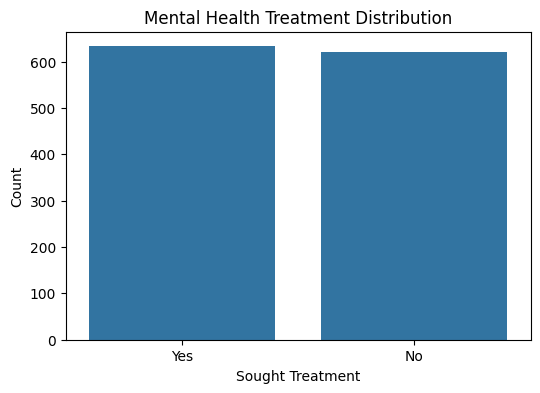

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='treatment')
plt.title('Mental Health Treatment Distribution')
plt.xlabel('Sought Treatment')
plt.ylabel('Count')
plt.show()

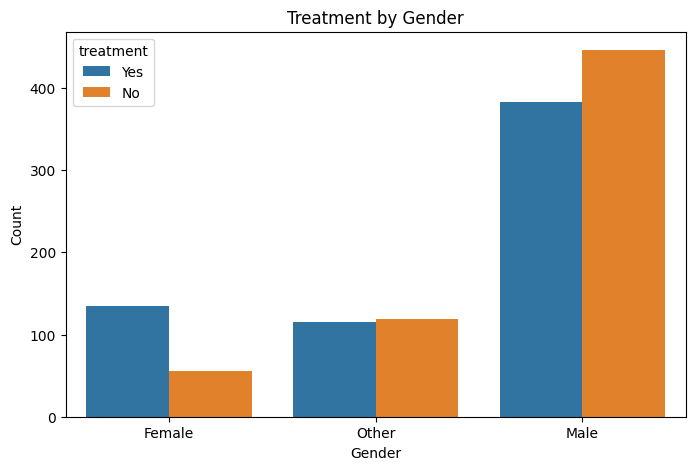

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Gender', hue='treatment')
plt.title('Treatment by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

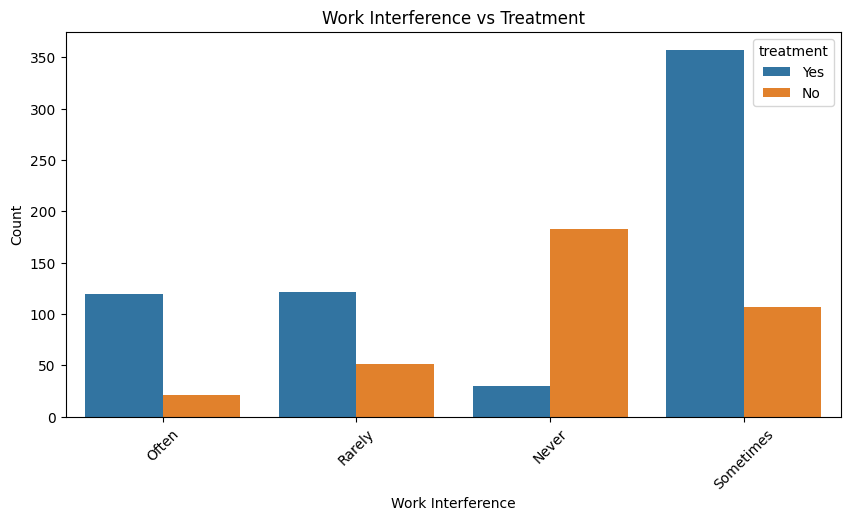

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='work_interfere', hue='treatment')
plt.title('Work Interference vs Treatment')
plt.xlabel('Work Interference')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

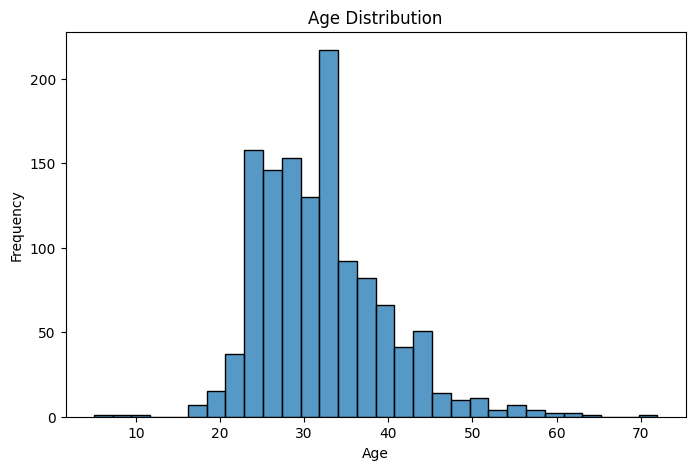

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## Save Cleaned Data

In [18]:
df.to_csv('../data/cleaned_mental_health.csv', index=False)

## Key Findings

- A substantial portion of respondents reported seeking mental health treatment.
- Treatment patterns vary across gender groups.
- Work interference appears related to whether respondents sought treatment.
- The dataset required cleaning, especially for age and gender fields.